# AP 155 Lab Exercise
---
## Exercise 6: Eigenfunctions and Eigenvalues of a Hamiltonian

_Instructions_: 
- **Problem 1 Report figure:** First 5 wavefunctions of the harmonic oscillator.
- **Problem 2 Report figure:** Energy analysis and plotting of probability density.
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Agbay, Tristan Michael 
- _Student No._: 2024-00281
- _Section_: THU-WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->

### Report discussion

Unlike classical particles that can rest at the bottom of a potential well with zero motion, quantum particles behave as waves governed by the Schrödinger equation. They exist in discrete energy states and can never be completely at rest.

In a quantum harmonic oscillator, a trapped particle acts like a spread-out wave inside a U-shaped potential well rather than a classical marble rolling in a bowl. It can never sit completely still at the very bottom, meaning even its lowest state retains a non-zero baseline energy called zero-point energy. Building a matrix Hamiltonian on a discrete spatial grid allows us to directly solve for these fixed energy levels and their matching wave shapes.

![First 5 wavefunctions of the harmonic oscillator](QHOscillator.png)

Figure 1: First 5 wavefunctions of the harmonic oscillator

Problem 1 demonstrated how a grid-based numerical algorithm was used to solve the 1D quantum harmonic oscillator. Continuous space was divided into discrete grid points, where a finite-difference matrix represented kinetic energy and a diagonal matrix represented potential energy. Adding these formed the Hamiltonian matrix, which np.linalg.eigh diagonalized to find the energy levels and wavefunctions.

Figure 1 displays the wavefunctions shifted to sit on their corresponding energy levels over the potential curve. The lowest state sits at 0.400 energy instead of zero, demonstrating quantum zero-point energy. The higher energy levels increase in equal steps of 0.800. Each state $n$ features exactly $n$ nodes where the wave crosses zero, alternating between even and odd symmetry. Finally, the wave edges spill past the dashed potential boundaries before dropping to zero, providing a visual proof of quantum tunneling and particle confinement.

![First 50](HO_UEF.png)

Figure 2: Calculated Energy Levels Compared with Theoretical Values

In Problem 2, adding an electric field shifts the center of the parabolic potential well to the left. As shown in Figure 2, numerical energy levels start drifting above theoretical values at higher energy states. This deviation occurs because higher quantum states spread much wider across space. When these broad wavefunctions reach the fixed edges of the simulation grid, the artificial boundary forces them to zero prematurely, effectively squeezing the wave and inflating its computed kinetic energy.

![Gstate and prob density](GroundState.png)

Figure 3: Spatial Distribution of the Ground State in a Uniform Electric Field

Figure 3 shows a dual y-axis (potential and probability density) because of them being fundamentally different physical quantities. Potential energy ranges across broad values up to fourteen, whereas probability density measures probability per unit length and peaks well below one. Using a single y-axis would squash the probability curve into an unreadable flat line along the bottom. Separate, independently scaled axes let us visually compare both curves on the same plot, clearly showing how the ground-state wave sits neatly inside the shifted potential minimum. The plot reveals a smooth curve centered precisely at the bottom of the shifted potential minimum. Crucially, calculating the total area under this probability density curve yields an exact value of 1.0, proving that the wavefunction is properly normalized.


### Other comments
- I am currently taking Physics 108, so I don't really have a firm grasp on quantum mechanics (YET). Of course, this does not really excuse me from not doing well at this subject, so I asked my seatmate for help. Thanks, Clarke, for helping me in this exercise!
- I debugged my problem code, and I fixed some typos


---
## Section 2: Code

### Problem 1: Hamiltonian Matrix and its Eigs

The time-independent Schrödinger equation is:

$$
\left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\hat{V}(x)\right]\psi(x)=\left[\hat{T} + \hat{V} \right]\psi=E_n\psi(x).
$$

In quantum mechanics, we can represent operators (e.g. $\hat{T}$ and $\hat{V}$) as matrices, while the quantum state (in this case, $\psi$) is written as an $N \times 1$ vector

$$ \psi = 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix}
$$

where $\psi_i$ represents the value of the wave function at $x_i$. Now, we know that $\left[\hat{V}(x)\psi(x)\right]|_{x_i} \equiv V(x_i)\psi(x_i) = V_i \psi_i$. We can write this statement as:

$$\hat{V}
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = 
\begin{bmatrix}
V_1\psi_1 \\
V_2\psi_2 \\
\vdots \\
V_i\psi_i \\
\vdots \\
V_N\psi_N
\end{bmatrix}
$$

This relation only holds true when $\hat{V}$ is an $N \times N$ square diagonal matrix of the form:

$$
\boxed{\hat{V}=
\begin{pmatrix}
V_1 & 0 & 0 & \cdots & 0 & 0 & 0 \\
0 & V_2 & 0 & \cdots & 0 & 0 & 0 \\
0 & 0 & V_3 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & V_i & 0 & 0 \\
0 & 0 & 0 & \cdots & 0 & \ddots & 0 \\
0 & 0 & 0 & \cdots & 0 & 0 & V_N
\end{pmatrix}
}
$$

where $V_i$ denotes the potential's value at $x_i$. This is then what we call the "matrix representation" of the operator $\hat{V}$! At least, in the position basis -- more info on 142 or 241 :)

**(a)** On a piece of paper, find the matrix representation of the kinetic energy operator $\hat{T} \equiv \cfrac{-\hbar^2}{2m}\cfrac{\partial^2}{\partial x^2}$. Use the fact that 

$$
f''(x_i)=
\frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{(\Delta x)^2}
$$

The first step of this problem would be to solve
$$
\cfrac{\partial^2}{\partial x^2}\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = \ ?
$$

and then to find a matrix representation for $\cfrac{\partial^2}{\partial x^2}$ operator. Your result should look like a square diagonal matrix

$$
\boxed{\hat{T}=
-\frac{\hbar^2}{2m(\Delta x)^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & -2 & 1 & \ddots & \vdots \\
0 & 0 & 0 & 1 & -2 & \ddots & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & \cdots & 0 & 1 & -2
\end{pmatrix}
}
$$

**(b)** Write a function that outputs the Hamiltonian ($\hat{T} + \hat{V})$ matrix `hamiltonian(x_pos, potential_array, mass)` where `x_pos` and `potential_array` are both $N \times 1$ arrays (vectors), while `mass` is a scalar. The former represents position coordinates while the latter represents potential values at these coordinates. You might want to use `np.eye()`.

**(c)** Test your `hamiltonian()` function for the case where $V(x) = \cfrac{1}{2}m\omega^2x^2$. Obtain the first $N=5$ eigenfunctions of your Hamiltonian using `np.linalg.eigh()`, and obtain their corresponding eigenvalues. Plot the eigenfunctions, then offset each to its corresponding eigenvalue. In essence, you will plot $f_n$ where

$$
f_n = \psi_n + E_n
$$

Lastly, overlay the harmonic potential $V$ on the plot itself. Assume that $m=\hbar=1$ while $\omega=0.8$. 

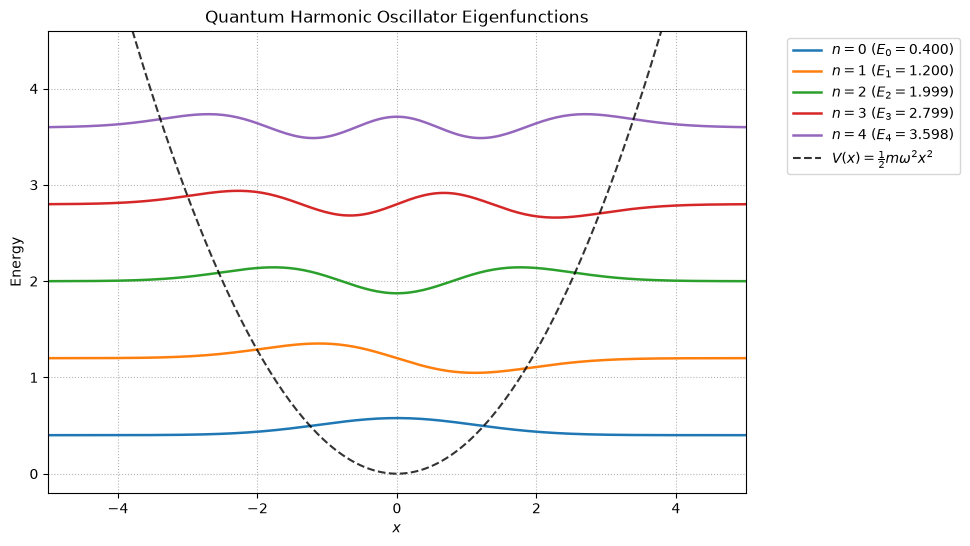

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("default") # intentionally tried dark mode but did not know how to revert

# Physical constants & parameters
m = 1.0
w = 0.8


def build_hamiltonian(x_pos, potential_array, particle_mass, h_bar=1):
    grid_size = len(x_pos)
    delta_x = x_pos[1] - x_pos[0]

    # Tridiagonal kinetic energy operator
    diag_main = -2.0 * np.eye(grid_size)
    diag_upper = np.eye(grid_size, k=1)
    diag_lower = np.eye(grid_size, k=-1)

    kinetic_matrix = (
        -(h_bar**2)
        / (2 * particle_mass * delta_x**2)
        * (diag_main + diag_upper + diag_lower)
    )

    # Diagonal potential energy operator
    potential_matrix = np.diag(potential_array)

    return kinetic_matrix + potential_matrix

# Expanded grid domain to eliminate truncation artifacts
x_vals = np.linspace(-5, 5, 200)
dx = x_vals[1] - x_vals[0]

# Define harmonic potential
V_vals = 0.5 * m * (w**2) * (x_vals**2)

# Solve system Hamiltonian
H_matrix = build_hamiltonian(x_vals, V_vals, m)
evals, evecs = np.linalg.eigh(H_matrix)

# Plotting setup
plt.figure(figsize=(9, 6))
scale_factor = 0.25 

for i in range(5):
    psi = evecs[:, i]
    psi_norm = psi / np.sqrt(np.sum(np.abs(psi) ** 2) * dx)
    if psi_norm[np.argmax(np.abs(psi_norm))] < 0:
        psi_norm = -psi_norm

    # Plot wavefunctions offset by energy eigenvalue E_i
    plt.plot(
        x_vals,
        scale_factor * psi_norm + evals[i],
        linewidth=1.8,
        label=f"$n={i}$ ($E_{i} = {evals[i]:.3f}$)",)

# Plot potential curve V(x)
plt.plot(
    x_vals,
    V_vals,
    color="black",
    linestyle="--",
    alpha=0.8,
    linewidth=1.5,
    label="$V(x) = \\frac{1}{2}m\\omega^2 x^2$",)

plt.xlim(-5, 5)
plt.ylim(-0.2, max(evals[:5]) + 1.0)
plt.xlabel("$x$")
plt.ylabel("Energy")
plt.title(f"Quantum Harmonic Oscillator Eigenfunctions")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, color="black", linestyle=":", alpha=0.3)

plt.savefig("QHOscillator.png", dpi=300, bbox_inches="tight")
plt.show()

#### Problem 1 code summary

The kinetic energy matrix was constructed using a finite-difference approximation, while the potential energy matrix was built across the spatial grid. Adding these two matrices created the total Hamiltonian matrix. The np.linalg.eigh function was then used to calculate the energy eigenvalues and wavefunctions. Each wavefunction was normalized so its total probability equals one. Finally, the first five wavefunctions were plotted shifted by their energy levels on top of the potential curve.


---

### Problem 2: Harmonic Oscillator in an Electric Field

The effective potential of an oscillator immersed in a uniform electric field is

$$
V(x) = \cfrac{1}{2}m\omega^2x^2 + qEx
$$

where $q$ is the particle's charge, and $E$ is the strength of the applied uniform electric field.

**(a)** Assume that the particle is an electron and it is immersed in a field of strength $E=q^{-1}$. Plot 100 eigenenergies of the resulting Hamiltonian, and compare it with the theoretical value of

$$
E_n = \hbar \omega \left(n+\cfrac{1}{2} \right) - \cfrac{q^2 E^2}{2m \omega^2}
$$

Did you get the expected result? Why or why not?

**(b)** Plot the potential and the probability density of the ground state. Does the plot make sense? 

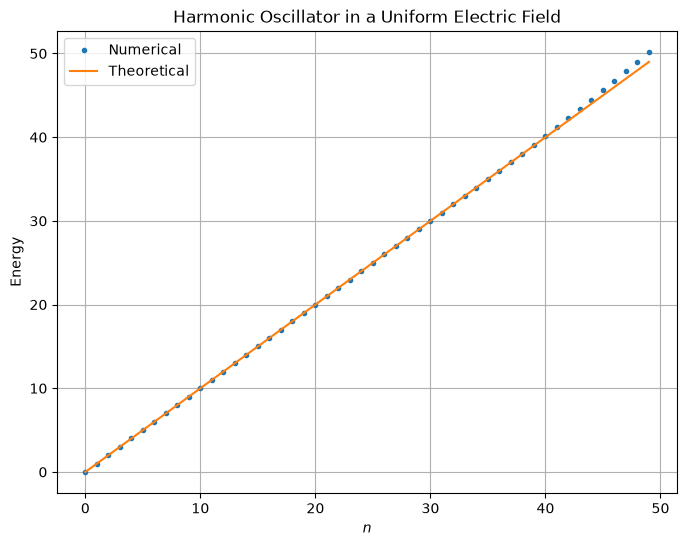

In [66]:
import numpy as np
import matplotlib.pyplot as plt


# Constants 
charge_q = 1
e_field = 1 / charge_q
x_vals_ext = np.linspace(-10, 10, 1000)


V_eff = 0.5 * m * w**2 * x_vals_ext**2 + charge_q * e_field * x_vals_ext

# Solve for eigenvalues and eigenvectors with the new potential
H_field = build_hamiltonian(x_vals_ext, V_eff, m)
evals_field, evecs_field = np.linalg.eigh(H_field)

# Extract first 50 energy levels and calculate theoretical equivalents
numerical_E = evals_field[:50]
n_states = np.arange(50)
theoretical_E = (1 * w * (n_states + 0.5)) - ((charge_q**2 * e_field**2) / (2 * m * w**2))

# Figure 1
plt.figure(figsize=(8, 6))
plt.plot(n_states, numerical_E, "o", markersize=3, label="Numerical")
plt.plot(n_states, theoretical_E, label="Theoretical")
plt.xlabel("$n$")
plt.ylabel("Energy")
plt.title("Harmonic Oscillator in a Uniform Electric Field")
plt.legend()
plt.grid(True)
plt.savefig("HO_UEF.png", dpi=300, bbox_inches="tight")
plt.show()

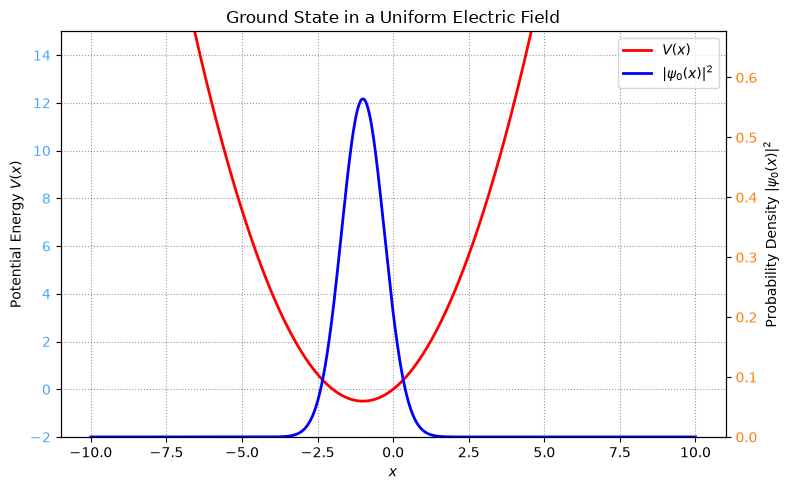

1.0


In [67]:
# Figure 2

# Continuous probability density normalization 
ground_state_psi = evecs_field[:, 0]
dx = x_vals_ext[1] - x_vals_ext[0]  # Ensure step size matches x_vals_ext
prob_density = (np.abs(ground_state_psi) ** 2) / dx

fig, ax1 = plt.subplots(figsize=(8, 5))

# left y-axis: Potential Energy V(x)
ax1.plot(x_vals_ext, V_eff, color="red", linewidth=2, label=r"$V(x)$")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"Potential Energy $V(x)$", color="black")
ax1.tick_params(axis="y", labelcolor="#4da6ff")
ax1.set_ylim(-2, 15)  # Zoomed to emphasize the bottom of the well
ax1.grid(True, color="black", linestyle=":", alpha=0.4)

# right y-axis: Ground State Probability Density
ax2 = ax1.twinx()
ax2.plot(x_vals_ext, prob_density, color="blue", linewidth=2, label=r"$|\psi_0(x)|^2$",)
ax2.set_ylabel(r"Probability Density $|\psi_0(x)|^2$", color="black")
ax2.tick_params(axis="y", labelcolor="#ff7f0e")
ax2.set_ylim(0, max(prob_density) * 1.2)

# Combined Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.title("Ground State in a Uniform Electric Field")
fig.tight_layout()
plt.savefig("GroundState.png", dpi=300, bbox_inches="tight")
plt.show()

# to check if the prob density is truly equal to 1 (spoiler, it is 1 (yey!))
integral = np.sum(prob_density * dx)
print(integral)

#### Problem 2 code summary

The code calculates the Hamiltonian of a harmonic oscillator in a uniform electric field. The first 50 energy levels are computed and compared with theoretical values using np.linalg.eigh(). Finally, the ground-state eigenfunction is used to plot the probability density and the shifted potential.

---

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)